This file trains the feature-extracting time-series encoder using the processed samples. The encoder is trained to compress the multi-scale time-series windows into a single dense feature vector (ts_encoding). To this end, the model is trained for two stages on proxy tasks.

Model Architecture:

A  ***Global-context encoder*** (**GRU**) is used to processes the 100-day global_stock window. Its final hidden state is used as the initial state for the LocalEncoder's LSTM for providing long-term context.


The ***Local Encoder*** is composed of the following components:

*   ***stock_embedding***: This is a learned, 16-dimension, per-stock feature.  Every one of the 30 stocks has its individual leanred stock_embedding.
*   ***Stock Channel***: The main channel to process the *local_stock* data. A **FiLMLayer** uses the learned **stock_embedding** to make the 30-day local_stock input "asset-aware". This is then passed through a **1D-CNN** (pattern extraction) and an **LSTM**.
*   **Macro Channel**: A separate LSTM processes the 30-day local_macro (QQQ) data.
*   A **Cross-Attention layer** allows the Stock Channel to query the Macro Channel. Intended to provide macro-context for the encoder.

The final encoding is the **concatenation of** the final hidden state of the simple stock_lstm channel and that of the channel after cross attention.(128-dim)

The following "temporary" components are used when training the encoder on the proxy tasks; they are dropped in the inference process for generating features for the downstream XGBoost.

*   Decoder (LSTM): Used to reconstruct the 30-day local window for pre-training.
*   PredictionHead (MLP): Used to predict the 5-day future label window for fine-tuning.


A two-stage training schedule is adopted:

Phase 1, Reconstruction: The TimeSeriesEncoder and Decoder are trained as a Denoising Autoencoder. The objective is to reconstruct the original 30-day local_stock input, forcing the encoder to learn a compressed representation of the given time series.

Phase 2, Reconstruction + Prediction: Designed to make the encoder's features useful for forecasting. The PredictionHead is added, and the full model is fine-tuned on a combined loss (Reconstruction + 5-day Prediction).

The final pre-trained model weights are saved in ts_multitask_best.pth.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%pip install tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import random
import matplotlib.pyplot as plt

pd.options.mode.chained_assignment = None

Mounted at /content/drive


In [ ]:
BASE_DIR = '/content/drive/MyDrive/'
SAMPLES_DIR = os.path.join(BASE_DIR, 'processed_samples/')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'ts_autoencoder_best.pth')

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 64
NUM_EPOCHS = 250
VALIDATION_SPLIT_RATIO = 0.15
EARLY_STOPPING_PATIENCE = 15

# Global Window: 100 days, 5 features (OHLCV)
GLOBAL_INPUT_DIM = 5
# Local Window: 30 days, 20 features
LOCAL_STOCK_INPUT_DIM = 20
# FiLM layer modulates 14 non-time features
OHLCV_PLUS_INDICATORS_DIM = 14
# Time features
TIME_FEAT_DIM = 6

STOCK_EMBED_DIM = 16
HIDDEN_DIM = 64
CNN_OUT_CHANNELS = 32
NUM_HEADS = 4
DROPOUT_RATE = 0.1

MASK_PROB = 0.1

In [ ]:
def init_hidden_state(context_vector, num_layers, num_directions):
    """
    Prepare initial hidden and cell states for LSTM/GRU.
    context_vector: The vector to use for initialization.
    num_directions: 1 for unidirectional, 2 for bidirectional.

    """
    batch_size, hidden_dim = context_vector.shape
    # Shape becomes (num_layers * num_directions, batch_size, hidden_dim)
    h_0 = context_vector.unsqueeze(0).repeat(num_layers * num_directions, 1, 1)
    c_0 = context_vector.unsqueeze(0).repeat(num_layers * num_directions, 1, 1)
    return h_0, c_0

class GlobalContextEncoder(nn.Module):
    """
    Global Context Encoder
    Processes a long-term time series (100 days here) to produce a single
    context vector summarizing the market regime or long-term trend.

    Chose GRU because it is more light-weighted than LSTM.

    """
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
    def forward(self, long_term_series):

        _, h_n = self.gru(long_term_series)
        # Take the hidden state of the last layer
        # Shape: (batch_size, hidden_dim)
        return h_n[-1]

class FiLMLayer(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM) Layer.
    It generates a scaling (gamma) and shifting (beta) parameter
    from a conditional vector (the stock embedding here) and applies
    it to an input time series.

    """
    def __init__(self, conditional_dim, feature_dim):
        super().__init__()
        self.gamma_projection = nn.Linear(conditional_dim, feature_dim)# Shape: (batch, feature_dim)
        self.beta_projection = nn.Linear(conditional_dim, feature_dim)
    def forward(self, series_data, conditional_vector):
        # series_data: The time series data to modulate. Shape: (batch_size, seq_len, feature_dim)
        # Add a dimension for seq_len: (batch, 1, feature_dim)
        gamma = self.gamma_projection(conditional_vector).unsqueeze(1)
        beta = self.beta_projection(conditional_vector).unsqueeze(1)
        return gamma * series_data + beta

class LocalEncoder(nn.Module):
    """
    The Core Local Encoder
    Processes the 30-day short-term window
    Conditioned on global context through the FiLM layer. Two parallel channels (stock, macro),
    fussed with cross-attention.

    """
    def __init__(self, stock_feat_dim, ohlcv_feat_dim, time_feat_dim, macro_feat_dim,
                 stock_embed_dim, hidden_dim, cnn_out_channels, num_heads, dropout_rate):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.ohlcv_feat_dim = ohlcv_feat_dim
        self.film = FiLMLayer(stock_embed_dim, ohlcv_feat_dim)

        # "Local" stock Channel (CNN -> LSTM)
        self.stock_cnn = nn.Conv1d(stock_feat_dim, cnn_out_channels, kernel_size=3, padding=1)
        self.stock_lstm = nn.LSTM(cnn_out_channels, hidden_dim, batch_first=True)
        # "Global" Channel (QQQ)
        self.macro_lstm = nn.LSTM(macro_feat_dim, hidden_dim, batch_first=True)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)

        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, stock_series, macro_series, stock_embedding, global_context_vector):
        x_ohlcv = stock_series[:, :, :self.ohlcv_feat_dim]
        x_time = stock_series[:, :, self.ohlcv_feat_dim:]
        x_ohlcv_modulated = self.film(x_ohlcv, stock_embedding)
        x_stock_final = torch.cat([x_ohlcv_modulated, x_time], dim=2)

        # CNN expects (batch, channels, length)
        cnn_out = F.relu(self.stock_cnn(x_stock_final.permute(0, 2, 1)).permute(0, 2, 1))
        cnn_out = self.dropout(cnn_out)

        h0_stock, c0_stock = init_hidden_state(global_context_vector, 1, 1)
        h_stock, _ = self.stock_lstm(cnn_out, (h0_stock, c0_stock))
        h_stock = self.dropout(h_stock)

        h_macro, _ = self.macro_lstm(macro_series)

        attn_output, _ = self.attention(h_stock, h_macro, h_macro)
        h_enhanced_stock = self.layer_norm(h_stock + self.dropout(attn_output))

        return h_stock[:, -1, :], h_enhanced_stock[:, -1, :]

class TimeSeriesEncoder(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        self.global_encoder = GlobalContextEncoder(kwargs['global_input_dim'], kwargs['hidden_dim'])
        self.local_encoder = LocalEncoder(
            kwargs['local_stock_input_dim'], kwargs['ohlcv_plus_indicators_dim'], kwargs['time_feat_dim'],
            kwargs['local_stock_input_dim'], kwargs['stock_embed_dim'], kwargs['hidden_dim'],
            kwargs['cnn_out_channels'], kwargs['num_heads'], kwargs['dropout_rate']
        )
        self.output_dim = kwargs['hidden_dim'] * 2

    def forward(self, global_series, stock_series, macro_series, stock_embedding):
        global_context = self.global_encoder(global_series)
        h_stock_last, h_enhanced_last = self.local_encoder(stock_series, macro_series, stock_embedding, global_context)

        # Residual Aggregation
        return torch.cat([h_stock_last, h_enhanced_last], dim=1)

"""
*************
Decoder used for the reconstruction task

*************
"""

class Decoder(nn.Module):
    """
    Decodes the ts_encoding back into a 30-day sequence using
    the encoding as the initial hidden state.
    """
    def __init__(self, encoding_dim, hidden_dim, output_dim, seq_len, dropout_rate):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.fc_h = nn.Linear(encoding_dim, hidden_dim)
        self.fc_c = nn.Linear(encoding_dim, hidden_dim)

        self.decoder_input_dim = 16 # arbitrary 
        self.start_token_embed = nn.Parameter(torch.randn(1, 1, self.decoder_input_dim))

        self.lstm = nn.LSTM(self.decoder_input_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, encoding):
        batch_size = encoding.shape[0]

        h_0 = self.fc_h(encoding).unsqueeze(0)
        c_0 = self.fc_c(encoding).unsqueeze(0)

        # Shape: (batch_size, seq_len, decoder_input_dim)
        decoder_input_seq = self.start_token_embed.repeat(batch_size, self.seq_len, 1)

        x, _ = self.lstm(decoder_input_seq, (h_0, c_0))
        x = self.dropout(x)

        output_sequence = self.fc_out(x) # Shape (Batch_size, 30, output_dim)
        return output_sequence


class Autoencoder(nn.Module):
    """The complete Autoencoder model for pre-training."""
    def __init__(self, encoder_kwargs, decoder_kwargs):
        super().__init__()
        self.encoder = TimeSeriesEncoder(**encoder_kwargs)
        self.decoder = Decoder(**decoder_kwargs)

    def forward(self, global_series, stock_series, macro_series, stock_embedding):
        ts_encoding = self.encoder(global_series, stock_series, macro_series, stock_embedding)
        reconstructed_sequence = self.decoder(ts_encoding)
        return reconstructed_sequence

In [ ]:
def apply_masking(tensor, mask_prob):
    """
    Randomly sets entire timesteps (features) to zero to enhence robostness

    """
    if mask_prob == 0 or tensor.ndim != 2: # Only apply to 2D tensors
        return tensor

    masked_tensor = tensor.clone()
    seq_len = tensor.shape[0]
    num_timesteps_to_mask = int(seq_len * mask_prob)

    if num_timesteps_to_mask == 0:
      return masked_tensor 
    
    # Randomly select indices of timesteps to mask
    masked_indices = random.sample(range(seq_len), num_timesteps_to_mask)
    masked_tensor[masked_indices, :] = 0.0
    return masked_tensor

class StockTimeSeriesDataset(Dataset):
    def __init__(self, file_paths, stock_to_idx, mask_prob=0.0):
        self.file_paths = file_paths
        self.stock_to_idx = stock_to_idx
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        data = torch.load(file_path, weights_only=False)

        local_stock_input = apply_masking(data['local_stock'], self.mask_prob)
        reconstruction_target = data['local_stock']
        stock_symbol = data['metadata']['stock_symbol']
        stock_idx = self.stock_to_idx.get(stock_symbol, -1)
        if stock_idx == -1:
            raise ValueError(f"Stock symbol {stock_symbol} not in stock_to_idx map.")

        return {
            'global_stock': data['global_stock'],
            'local_stock': local_stock_input,
            'local_macro': data['local_macro'],
            'reconstruction_target': reconstruction_target,
            'label': data['label'],
            'stock_idx': torch.tensor(stock_idx, dtype=torch.long)
        }

In [ ]:
class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after a given patience.

    """
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model, embedding_layer):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model, embedding_layer)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model, embedding_layer)
            self.counter = 0

    def save_checkpoint(self, val_loss, model, embedding_layer):
        """Saves model and embedding layer when validation loss decreases."""
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'embedding_layer_state_dict': embedding_layer.state_dict(),
            'val_loss': val_loss
        }
        torch.save(checkpoint, self.path)
        self.val_loss_min = val_loss

**Loading Samples**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_val_dir = os.path.join(SAMPLES_DIR, 'train')
test_dir = os.path.join(SAMPLES_DIR, 'test')

all_train_val_files = [os.path.join(train_val_dir, f) for f in os.listdir(train_val_dir) if f.endswith('.pt')]
test_files = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith('.pt')]

all_train_val_files.sort(key=lambda x: os.path.basename(x).split('_')[1].replace('.pt', ''))
test_files.sort(key=lambda x: os.path.basename(x).split('_')[1].replace('.pt', ''))

split_idx = int(len(all_train_val_files) * (1 - VALIDATION_SPLIT_RATIO))
train_files = all_train_val_files[:split_idx]
val_files = all_train_val_files[split_idx:]

print(f"Total training samples: {len(train_files)}")
print(f"Total validation samples: {len(val_files)}")
print(f"Total test samples: {len(test_files)}")

# Create stock-to-index mapping for embeddings
all_symbols = set()
for f in tqdm(all_train_val_files, desc="Scanning for symbols"):
    try:
        meta = torch.load(f, weights_only=False)['metadata']
        all_symbols.add(meta['stock_symbol'])
    except Exception as e:
        print(f"Could not load metadata from {f}. Error: {e}")

stock_to_idx = {symbol: i for i, symbol in enumerate(sorted(list(all_symbols)))}
NUM_UNIQUE_STOCKS = len(stock_to_idx)
print(f"\nFound {NUM_UNIQUE_STOCKS} unique stocks. Created mapping for embeddings.")
if NUM_UNIQUE_STOCKS == 0:
    raise RuntimeError("No stock symbols found in sample files.")

train_dataset = StockTimeSeriesDataset(train_files, stock_to_idx, mask_prob=MASK_PROB)
val_dataset = StockTimeSeriesDataset(val_files, stock_to_idx, mask_prob=0.0)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Using device: cpu
Total training samples: 1897
Total validation samples: 335
Total test samples: 558


Scanning files for symbols:   0%|          | 0/2232 [00:00<?, ?it/s]


Found 30 unique stocks. Created mapping for embeddings.


**Training Process for Phase 1: Reconstruction Task**

In [ ]:
encoder_params = {
    'global_input_dim': GLOBAL_INPUT_DIM,
    'local_stock_input_dim': LOCAL_STOCK_INPUT_DIM,
    'ohlcv_plus_indicators_dim': OHLCV_PLUS_INDICATORS_DIM,
    'time_feat_dim': TIME_FEAT_DIM,
    'stock_embed_dim': STOCK_EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'cnn_out_channels': CNN_OUT_CHANNELS,
    'num_heads': NUM_HEADS,
    'dropout_rate': DROPOUT_RATE
}

decoder_params = {
    'encoding_dim': HIDDEN_DIM * 2,
    'hidden_dim': HIDDEN_DIM,
    'output_dim': LOCAL_STOCK_INPUT_DIM, # Reconstructing local stock features
    'seq_len': 30, 
    'dropout_rate': DROPOUT_RATE
}

stock_embedding_layer = nn.Embedding(NUM_UNIQUE_STOCKS, STOCK_EMBED_DIM).to(device)

model = Autoencoder(encoder_params, decoder_params).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(list(model.parameters()) + list(stock_embedding_layer.parameters()),
                       lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)
early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, verbose=True, path=MODEL_SAVE_PATH)


"""
************
Training Loop

************
"""
history = {'train_loss': [], 'val_loss': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    stock_embedding_layer.train()
    running_train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in train_bar:
        global_stock = batch['global_stock'].to(device)
        local_stock = batch['local_stock'].to(device)
        local_macro = batch['local_macro'].to(device)
        target = batch['reconstruction_target'].to(device)
        stock_indices = batch['stock_idx'].to(device)

        embeddings = stock_embedding_layer(stock_indices)

        optimizer.zero_grad()
        outputs = model(global_stock, local_stock, local_macro, embeddings)

        # Only compute loss on the dynamic (non-time) features
        dynamic_outputs = outputs[:, :, :OHLCV_PLUS_INDICATORS_DIM]
        dynamic_target = target[:, :, :OHLCV_PLUS_INDICATORS_DIM]
        loss = criterion(dynamic_outputs, dynamic_target)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_train_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = running_train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    model.eval()
    stock_embedding_layer.eval()
    running_val_loss = 0.0

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
    with torch.no_grad():
        for batch in val_bar:
            global_stock = batch['global_stock'].to(device)
            local_stock = batch['local_stock'].to(device) # unmasked for validation
            local_macro = batch['local_macro'].to(device)
            target = batch['reconstruction_target'].to(device)
            stock_indices = batch['stock_idx'].to(device)

            embeddings = stock_embedding_layer(stock_indices)
            outputs = model(global_stock, local_stock, local_macro, embeddings)

            dynamic_outputs = outputs[:, :, :OHLCV_PLUS_INDICATORS_DIM]
            dynamic_target = target[:, :, :OHLCV_PLUS_INDICATORS_DIM]
            loss = criterion(dynamic_outputs, dynamic_target)

            running_val_loss += loss.item()
            val_bar.set_postfix(loss=loss.item())

    avg_val_loss = running_val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} -> Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

    scheduler.step(avg_val_loss)
    early_stopper(avg_val_loss, model, stock_embedding_layer)
    if early_stopper.early_stop:
        print("Early stopping triggered.")
        break

print("\n--- Training Finished ---")

print(f"Loading best model weights from: {MODEL_SAVE_PATH}")
checkpoint = torch.load(MODEL_SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
stock_embedding_layer.load_state_dict(checkpoint['embedding_layer_state_dict'])
print("Loaded best model and embedding layer weights.")
model.eval()
stock_embedding_layer.eval()

Epoch 1/250 [Train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/250 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1/250 -> Train Loss: 0.421463, Val Loss: 0.418937
Validation loss decreased (inf --> 0.418937).  Saving model ...


Epoch 2/250 [Train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 2/250 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

...

Epoch 249/250 -> Train Loss: 0.092975, Val Loss: 0.085641
EarlyStopping counter: 1 out of 15


Epoch 250/250 [Train]:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 250/250 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 250/250 -> Train Loss: 0.092812, Val Loss: 0.085268
Validation loss decreased (0.085605 --> 0.085268).  Saving model ...

--- Training Finished ---
Loading best model weights from: /content/drive/MyDrive/ts_autoencoder_best.pth
Loaded best model and embedding layer weights.


Embedding(30, 16)

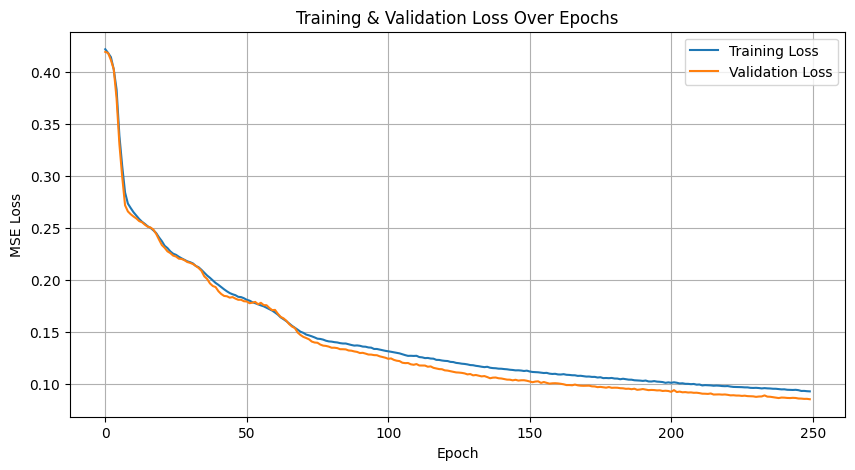

In [ ]:
# Visualize Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

Visualization


Loading Best Model for Evaluation
Loaded model and embedding layer from: /content/drive/MyDrive/ts_autoencoder_best.pth

Loading sample: LRCX_2025-01-15.pt

--- Sample Details ---
Metadata: {'stock_symbol': 'LRCX', 'local_start_date': '2025-01-15', 'p0_local': np.float64(75.3)}
Input Global Stock Shape:      torch.Size([1, 100, 5])
Input Local Stock Shape (raw): torch.Size([1, 30, 20])
Input Local Stock Shape (mask):torch.Size([1, 30, 20])
Input Local Macro Shape:       torch.Size([1, 30, 20])
Target Reconstruction Shape:   torch.Size([1, 30, 20])
Output Reconstructed Shape:    torch.Size([1, 30, 20])

Reconstruction MSE Loss (Dynamic Features Only) for this sample: 0.128458


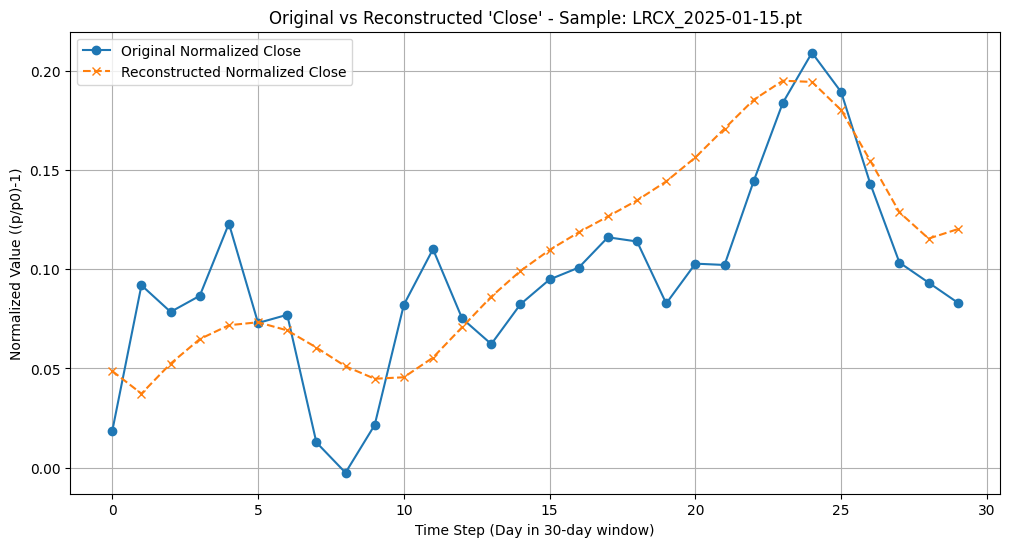

In [ ]:
import matplotlib.pyplot as plt # Make sure matplotlib is imported

print("Loading Best Model for Evaluation")
# Ensure the architecture is defined with the correct parameters from Cell 2
encoder_params_load = encoder_params.copy()
decoder_params_load = {
    'encoding_dim': HIDDEN_DIM * 2,
    'hidden_dim': HIDDEN_DIM,
    'output_dim': LOCAL_STOCK_INPUT_DIM, # Reconstructing 20 features
    'seq_len': 30,
    'dropout_rate': DROPOUT_RATE
}
eval_model = Autoencoder(encoder_params_load, decoder_params_load).to(device)
eval_embedding_layer = nn.Embedding(NUM_UNIQUE_STOCKS, STOCK_EMBED_DIM).to(device)
checkpoint = torch.load(MODEL_SAVE_PATH)
eval_model.load_state_dict(checkpoint['model_state_dict'])
eval_embedding_layer.load_state_dict(checkpoint['embedding_layer_state_dict'])

eval_model.eval()
eval_embedding_layer.eval()
print(f"Loaded model and embedding layer from: {MODEL_SAVE_PATH}")

if test_files:
     sample_path = test_files[100]
else:
    print("No validation or test files found to evaluate.")
    sample_path = None

if sample_path:
    print(f"\nLoading sample: {os.path.basename(sample_path)}")
    sample_data = torch.load(sample_path, weights_only=False)

    global_stock = sample_data['global_stock'].unsqueeze(0).to(device)
    local_stock_orig = sample_data['local_stock'].unsqueeze(0).to(device)
    local_macro = sample_data['local_macro'].unsqueeze(0).to(device)
    stock_idx_tensor = torch.tensor([stock_to_idx[sample_data['metadata']['stock_symbol']]], dtype=torch.long).to(device)
    local_stock_input = apply_masking(local_stock_orig.squeeze(0), MASK_PROB).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = eval_embedding_layer(stock_idx_tensor)
        reconstructed_sequence = eval_model(global_stock, local_stock_input, local_macro, embedding)

    print("\n--- Sample Details ---")
    print(f"Metadata: {sample_data['metadata']}")
    print(f"Input Global Stock Shape:      {global_stock.shape}")
    print(f"Input Local Stock Shape (raw): {local_stock_orig.shape}")
    print(f"Input Local Stock Shape (mask):{local_stock_input.shape}")
    print(f"Input Local Macro Shape:       {local_macro.shape}")
    print(f"Target Reconstruction Shape:   {local_stock_orig.shape}")
    print(f"Output Reconstructed Shape:    {reconstructed_sequence.shape}")

    loss_fn = nn.MSELoss()
    dynamic_outputs = reconstructed_sequence[:, :, :OHLCV_PLUS_INDICATORS_DIM]
    dynamic_target = local_stock_orig[:, :, :OHLCV_PLUS_INDICATORS_DIM]
    sample_loss = loss_fn(dynamic_outputs, dynamic_target)
    print(f"\nReconstruction MSE Loss (Dynamic Features Only) for this sample: {sample_loss.item():.6f}")

    LOCAL_FEATURES = [
        'open', 'high', 'low', 'close', 'volume',
        'sma_5', 'sma_20', 'ema_5', 'ema_20',
        'macd', 'macd_signal', 'macd_hist',
        'rsi_14', 'atr_14',
        'dow_cos', 'dow_sin',
        'dom_cos', 'dom_sin',
        'moy_cos', 'moy_sin'
    ]

    try:
        close_feature_index = LOCAL_FEATURES.index('high')

        original_close = local_stock_orig[0, :, close_feature_index].cpu().numpy()
        reconstructed_close = reconstructed_sequence[0, :, close_feature_index].cpu().numpy()

        plt.figure(figsize=(12, 6))
        plt.plot(original_close, label='Original Normalized Close', marker='o', linestyle='-')
        plt.plot(reconstructed_close, label='Reconstructed Normalized Close', marker='x', linestyle='--')
        plt.title(f"Original vs Reconstructed 'Close' - Sample: {os.path.basename(sample_path)}")
        plt.xlabel("Time Step (Day in 30-day window)")
        plt.ylabel("Normalized Value ((p/p0)-1)")
        plt.legend()
        plt.grid(True)
        plt.show()

    except ValueError:
        print(f"Could not find 'close' in the defined LOCAL_FEATURES list: {LOCAL_FEATURES}. Skipping plot.")
    except Exception as e:
        print(f"An error occurred during plotting: {e}")

**Phase 2: Multi-task training. Reconstruction + Prediction**

PredictionHead is added


In [ ]:
class PredictionHead(nn.Module):
    """
    Decodes the ts_encoding into a 5-day prediction sequence.
    Prediction contains only the 'close' price (output_dim=1).
    """
    def __init__(self, encoding_dim, hidden_dim, output_dim, seq_len, dropout_rate):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.fc_h = nn.Linear(encoding_dim, hidden_dim)
        self.fc_c = nn.Linear(encoding_dim, hidden_dim)
        self.decoder_input_dim = 16
        self.start_token_embed = nn.Parameter(torch.randn(1, 1, self.decoder_input_dim))
        self.lstm = nn.LSTM(self.decoder_input_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, encoding):
        batch_size = encoding.shape[0]
        h_0 = self.fc_h(encoding).unsqueeze(0)
        c_0 = self.fc_c(encoding).unsqueeze(0)

        # Create the input sequence (repeat start token 5 times)
        decoder_input_seq = self.start_token_embed.repeat(batch_size, self.seq_len, 1)
        x, _ = self.lstm(decoder_input_seq, (h_0, c_0))
        x = self.dropout(x)

        output_sequence = self.fc_out(x)
        return output_sequence

class MultiTaskAutoencoder(nn.Module):
    """
    The full model combining Encoder, Reconstruction Decoder, and Prediction Head.
    """
    def __init__(self, encoder, decoder, prediction_head):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.prediction_head = prediction_head

    def forward(self, global_series, stock_series, macro_series, stock_embedding):
        ts_encoding = self.encoder(global_series, stock_series, macro_series, stock_embedding)
        reconstructed_sequence = self.decoder(ts_encoding)
        predicted_sequence = self.prediction_head(ts_encoding)
        return reconstructed_sequence, predicted_sequence

In [ ]:
PHASE_2_SAVE_PATH = os.path.join(BASE_DIR, 'ts_multitask_best.pth')
LR_ENCODER_FINETUNE = 1e-5
LR_HEAD_NEW = 1e-4  # Larger LR for new prediction head; smaller LR for the previous task
NUM_EPOCHS_PHASE_2 = 150
EARLY_STOPPING_PATIENCE_PHASE_2 = 15
ALPHA = 0.2 # Weight for reconstruction loss. e.g. 0.2 = 20% recon, 80% pred

LABEL_FEATURES = ['open', 'high', 'low', 'close', 'volume']
PREDICTION_TARGET_FEATURE = 'close'
PREDICTION_TARGET_IDX = LABEL_FEATURES.index(PREDICTION_TARGET_FEATURE)

# Weights for [Day 1, Day 2, Day 3, Day 4, Day 5]
pred_loss_weights = torch.tensor([1.0, 0.8, 0.6, 0.4, 0.2], device=device).view(1, 5, 1)

def weighted_prediction_loss(outputs, targets, weights):
    """
    Calculates MSE loss with temporal weights.

    """
    squared_error = (outputs - targets) ** 2
    weighted_squared_error = squared_error * weights
    return torch.mean(weighted_squared_error)


In [ ]:
print("\nMulti-Task Training: Reconstruction + Prediction. ")

# Initialize architectures using params from Cell 2!!
encoder_phase1 = TimeSeriesEncoder(**encoder_params).to(device)
decoder_phase1 = Decoder(**decoder_params).to(device)
embedding_layer_phase1 = nn.Embedding(NUM_UNIQUE_STOCKS, STOCK_EMBED_DIM).to(device)

checkpoint_phase1 = torch.load(MODEL_SAVE_PATH, map_location=torch.device('cpu'))

# Create temporary Autoencoder model to load the state dict easily
temp_model = Autoencoder(encoder_params, decoder_params)
temp_model.load_state_dict(checkpoint_phase1['model_state_dict'])
encoder = temp_model.encoder.to(device)
decoder = temp_model.decoder.to(device)
stock_embedding_layer = nn.Embedding(NUM_UNIQUE_STOCKS, STOCK_EMBED_DIM).to(device)
stock_embedding_layer.load_state_dict(checkpoint_phase1['embedding_layer_state_dict'])

print(f"Loaded pre-trained weights from {MODEL_SAVE_PATH}")

prediction_head_params = {
    'encoding_dim': HIDDEN_DIM * 2,
    'hidden_dim': HIDDEN_DIM,
    'output_dim': 1, # Predicting 'close' price only
    'seq_len': 5,    # 5-day label window
    'dropout_rate': DROPOUT_RATE
}
prediction_head = PredictionHead(**prediction_head_params).to(device)

full_multitask_model = MultiTaskAutoencoder(encoder, decoder, prediction_head).to(device)

optimizer = optim.AdamW([
    {'params': full_multitask_model.encoder.parameters(), 'lr': LR_ENCODER_FINETUNE},
    {'params': stock_embedding_layer.parameters(), 'lr': LR_ENCODER_FINETUNE},
    {'params': full_multitask_model.decoder.parameters(), 'lr': LR_ENCODER_FINETUNE},
    {'params': full_multitask_model.prediction_head.parameters(), 'lr': LR_HEAD_NEW}
], lr=LR_HEAD_NEW, weight_decay=WEIGHT_DECAY)

recon_criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)
early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE_PHASE_2, verbose=True, path=PHASE_2_SAVE_PATH)

# Training Loop
history_phase2 = {'train_loss': [], 'val_loss': [], 'train_recon_loss': [], 'train_pred_loss': [], 'val_recon_loss': [], 'val_pred_loss': []}
try:
    if not isinstance(train_loader.dataset, StockTimeSeriesDataset) or 'label' not in train_loader.dataset[0]:
        print("Re-initializing DataLoaders with updated StockTimeSeriesDataset...")
        train_dataset = StockTimeSeriesDataset(train_files, stock_to_idx, mask_prob=MASK_PROB)
        val_dataset = StockTimeSeriesDataset(val_files, stock_to_idx, mask_prob=0.0)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
except Exception as e:
    print(f"Could not check dataset type, proceeding. Error: {e}")


for epoch in range(NUM_EPOCHS_PHASE_2):
    full_multitask_model.train()
    stock_embedding_layer.train()

    running_train_loss = 0.0
    running_train_recon_loss = 0.0
    running_train_pred_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Phase 2 Epoch {epoch+1}/{NUM_EPOCHS_PHASE_2} [Train]")
    for batch in train_bar:
        global_stock = batch['global_stock'].to(device)
        local_stock = batch['local_stock'].to(device)
        local_macro = batch['local_macro'].to(device)
        recon_target = batch['reconstruction_target'].to(device)
        pred_target = batch['label'][:, :, PREDICTION_TARGET_IDX].unsqueeze(-1).to(device)
        stock_indices = batch['stock_idx'].to(device)

        embeddings = stock_embedding_layer(stock_indices)

        optimizer.zero_grad()
        recon_output, pred_output = full_multitask_model(global_stock, local_stock, local_macro, embeddings)

        dynamic_recon_output = recon_output[:, :, :OHLCV_PLUS_INDICATORS_DIM]
        dynamic_recon_target = recon_target[:, :, :OHLCV_PLUS_INDICATORS_DIM]
        loss_recon = recon_criterion(dynamic_recon_output, dynamic_recon_target)

        loss_pred = weighted_prediction_loss(pred_output, pred_target, pred_loss_weights)
        total_loss = (ALPHA * loss_recon) + ((1 - ALPHA) * loss_pred)

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(full_multitask_model.parameters(), 1.0)
        optimizer.step()

        running_train_loss += total_loss.item()
        running_train_recon_loss += loss_recon.item()
        running_train_pred_loss += loss_pred.item()
        train_bar.set_postfix(TotalLoss=total_loss.item(), ReconLoss=loss_recon.item(), PredLoss=loss_pred.item())

    avg_train_loss = running_train_loss / len(train_loader)
    avg_train_recon_loss = running_train_recon_loss / len(train_loader)
    avg_train_pred_loss = running_train_pred_loss / len(train_loader)
    history_phase2['train_loss'].append(avg_train_loss)
    history_phase2['train_recon_loss'].append(avg_train_recon_loss)
    history_phase2['train_pred_loss'].append(avg_train_pred_loss)

    # Validation Phase
    full_multitask_model.eval()
    stock_embedding_layer.eval()
    running_val_loss = 0.0
    running_val_recon_loss = 0.0
    running_val_pred_loss = 0.0

    val_bar = tqdm(val_loader, desc=f"Phase 2 Epoch {epoch+1}/{NUM_EPOCHS_PHASE_2} [Val]")
    with torch.no_grad():
        for batch in val_bar:
            global_stock = batch['global_stock'].to(device)
            local_stock = batch['local_stock'].to(device)
            local_macro = batch['local_macro'].to(device)
            recon_target = batch['reconstruction_target'].to(device)
            pred_target = batch['label'][:, :, PREDICTION_TARGET_IDX].unsqueeze(-1).to(device)
            stock_indices = batch['stock_idx'].to(device)

            embeddings = stock_embedding_layer(stock_indices)
            recon_output, pred_output = full_multitask_model(global_stock, local_stock, local_macro, embeddings)

            loss_recon = recon_criterion(recon_output[:, :, :OHLCV_PLUS_INDICATORS_DIM], recon_target[:, :, :OHLCV_PLUS_INDICATORS_DIM])
            loss_pred = weighted_prediction_loss(pred_output, pred_target, pred_loss_weights)
            total_loss = (ALPHA * loss_recon) + ((1 - ALPHA) * loss_pred)

            running_val_loss += total_loss.item()
            running_val_recon_loss += loss_recon.item()
            running_val_pred_loss += loss_pred.item()
            val_bar.set_postfix(TotalLoss=total_loss.item())

    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_recon_loss = running_val_recon_loss / len(val_loader)
    avg_val_pred_loss = running_val_pred_loss / len(val_loader)
    history_phase2['val_loss'].append(avg_val_loss)
    history_phase2['val_recon_loss'].append(avg_val_recon_loss)
    history_phase2['val_pred_loss'].append(avg_val_pred_loss)

    print(f"Epoch {epoch+1} -> Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} (Recon: {avg_val_recon_loss:.6f}, Pred: {avg_val_pred_loss:.6f})")

    scheduler.step(avg_val_loss)
    early_stopper(avg_val_loss, full_multitask_model, stock_embedding_layer)
    if early_stopper.early_stop:
        print("Early stopping triggered")
        break

print("\n Training Finished ")
print(f"Loading best multi-task model weights from: {PHASE_2_SAVE_PATH}")
checkpoint_phase2 = torch.load(PHASE_2_SAVE_PATH, map_location=torch.device('cpu'))
full_multitask_model.load_state_dict(checkpoint_phase2['model_state_dict'])
stock_embedding_layer.load_state_dict(checkpoint_phase2['embedding_layer_state_dict'])
print("Loaded best multi-task model and embedding layer weights.")


Multi-Task Training: Reconstruction + Prediction. 
Loaded pre-trained weights from /content/drive/MyDrive/ts_autoencoder_best.pth


Phase 2 Epoch 1/150 [Train]:   0%|          | 0/30 [00:00<?, ?it/s]

Phase 2 Epoch 1/150 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1 -> Train Loss: 0.030505 | Val Loss: 0.025061 (Recon: 0.085059, Pred: 0.010061)
Validation loss decreased (inf --> 0.025061).  Saving model ...


Phase 2 Epoch 2/150 [Train]:   0%|          | 0/30 [00:00<?, ?it/s]

...

Phase 2 Epoch 119/150 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 119 -> Train Loss: 0.020852 | Val Loss: 0.020034 (Recon: 0.085037, Pred: 0.003784)
EarlyStopping counter: 14 out of 15


Phase 2 Epoch 120/150 [Train]:   0%|          | 0/30 [00:00<?, ?it/s]

Phase 2 Epoch 120/150 [Val]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 120 -> Train Loss: 0.020890 | Val Loss: 0.020044 (Recon: 0.085040, Pred: 0.003795)
EarlyStopping counter: 15 out of 15
Early stopping triggered

 Training Finished 
Loading best multi-task model weights from: /content/drive/MyDrive/ts_multitask_best.pth
Loaded best multi-task model and embedding layer weights.


Visualize Reconstruction + Prediction task

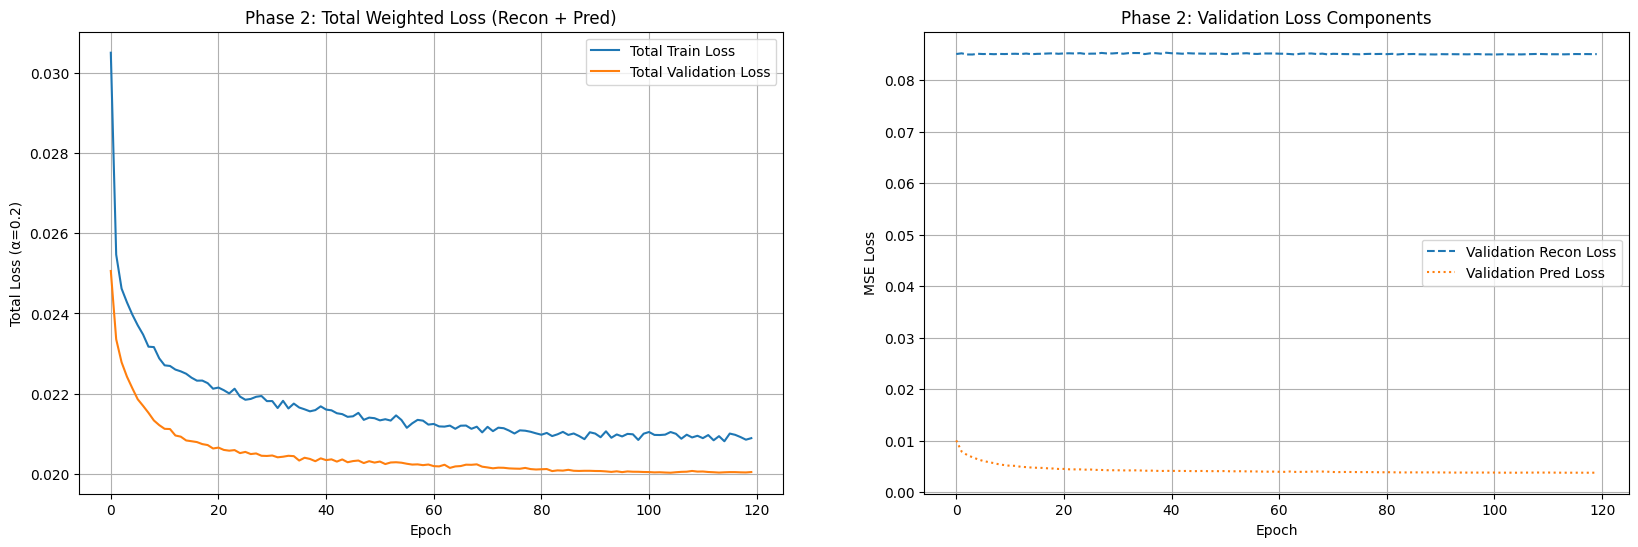

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot 1: Loss
ax1.plot(history_phase2['train_loss'], label='Total Train Loss')
ax1.plot(history_phase2['val_loss'], label='Total Validation Loss')
ax1.set_title('Phase 2: Total Weighted Loss (Recon + Pred)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel(f'Total Loss (α={ALPHA})')
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss
ax2.plot(history_phase2['val_recon_loss'], label='Validation Recon Loss', linestyle='--')
ax2.plot(history_phase2['val_pred_loss'], label='Validation Pred Loss', linestyle=':')
ax2.set_title('Phase 2: Validation Loss Components')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.legend()
ax2.grid(True)

plt.show()

Loading Best Phase 2 Model
Loaded multi-task model and embedding layer from: /content/drive/MyDrive/ts_multitask_best.pth

Loading sample: NVDA_2025-08-21.pt

Sample Details
Metadata: {'stock_symbol': 'NVDA', 'local_start_date': '2025-08-21', 'p0_local': np.float64(174.84)}
Input Global Stock Shape: torch.Size([1, 100, 5])
Input Local Stock Shape: torch.Size([1, 30, 20])
Input Local Macro Shape: torch.Size([1, 30, 20])
Target Reconstruction Shape: torch.Size([1, 30, 20])
Target Label Shape: torch.Size([1, 5, 5])
Output Reconstructed Shape: torch.Size([1, 30, 20])
Output Predicted Shape: torch.Size([1, 5, 1])

Reconstruction MSE Loss (Dynamic Features): 0.099574
Prediction MSE Loss (Weighted 'Close'):   0.000183


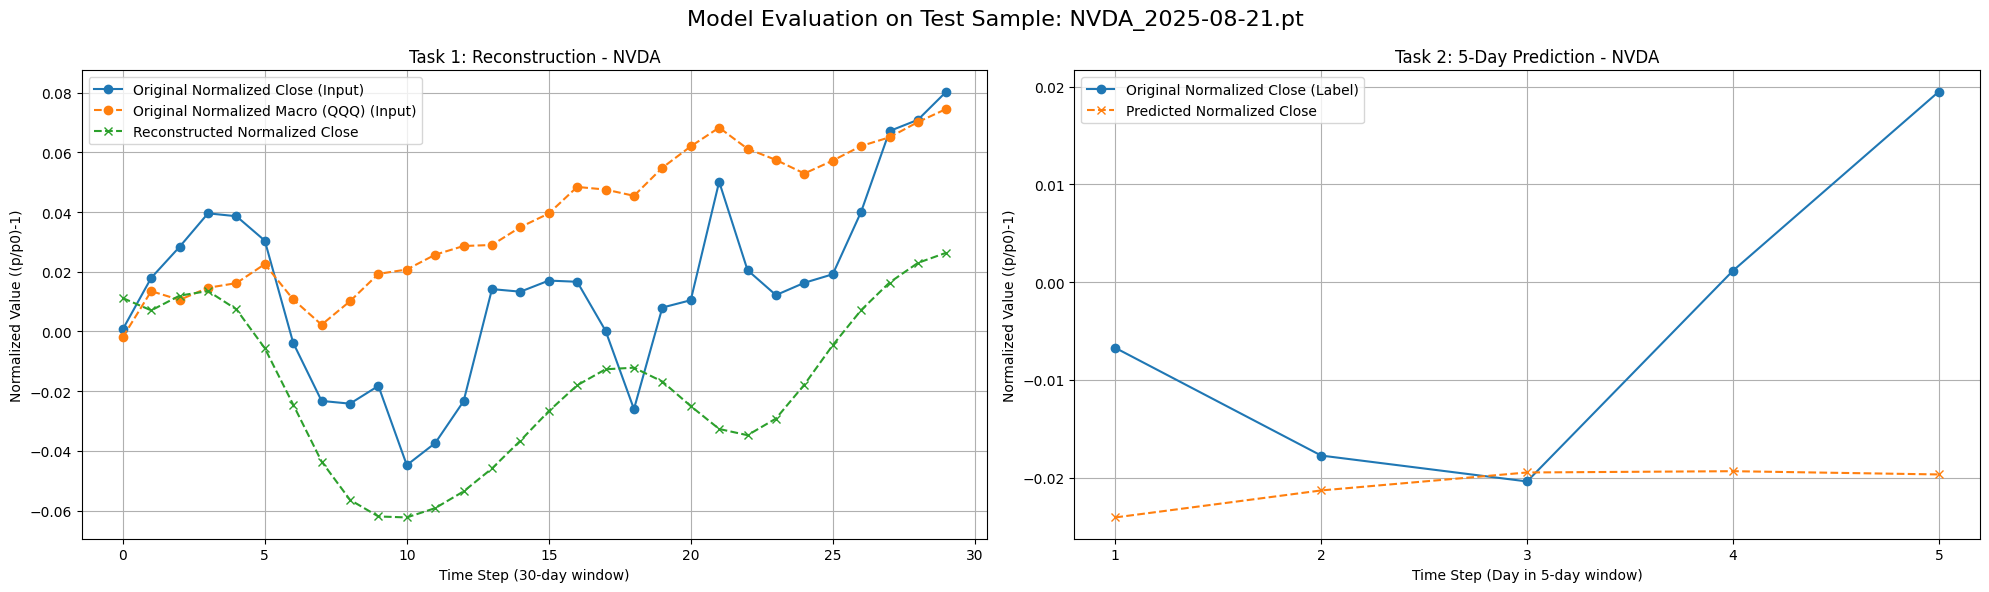

In [ ]:
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading Best Phase 2 Model")

encoder_params = {
    'global_input_dim': GLOBAL_INPUT_DIM,
    'local_stock_input_dim': LOCAL_STOCK_INPUT_DIM,
    'ohlcv_plus_indicators_dim': OHLCV_PLUS_INDICATORS_DIM,
    'time_feat_dim': TIME_FEAT_DIM,
    'stock_embed_dim': STOCK_EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'cnn_out_channels': CNN_OUT_CHANNELS,
    'num_heads': NUM_HEADS,
    'dropout_rate': DROPOUT_RATE
}

decoder_params = {
    'encoding_dim': HIDDEN_DIM * 2,
    'hidden_dim': HIDDEN_DIM,
    'output_dim': LOCAL_STOCK_INPUT_DIM, # Reconstructing local stock features
    'seq_len': 30, # Local window size
    'dropout_rate': DROPOUT_RATE
}

LABEL_WINDOW_SIZE = 5
try:
    prediction_head_params_load = {
        'encoding_dim': HIDDEN_DIM * 2,
        'hidden_dim': HIDDEN_DIM,
        'output_dim': 1, # Predicting 'close' price only
        'seq_len': LABEL_WINDOW_SIZE, # 5 days
        'dropout_rate': DROPOUT_RATE
    }

    eval_encoder = TimeSeriesEncoder(**encoder_params).to(device)
    eval_decoder = Decoder(**decoder_params).to(device)
    eval_pred_head = PredictionHead(**prediction_head_params_load).to(device)

    eval_model = MultiTaskAutoencoder(eval_encoder, eval_decoder, eval_pred_head).to(device)
    eval_embedding_layer = nn.Embedding(NUM_UNIQUE_STOCKS, STOCK_EMBED_DIM).to(device)

    checkpoint = torch.load(PHASE_2_SAVE_PATH, map_location=torch.device('cpu'))
    eval_model.load_state_dict(checkpoint['model_state_dict'])
    eval_embedding_layer.load_state_dict(checkpoint['embedding_layer_state_dict'])

    eval_model.eval()
    eval_embedding_layer.eval()
    print(f"Loaded multi-task model and embedding layer from: {PHASE_2_SAVE_PATH}")

except NameError as e:
    print(f"Error: Variables not defined; re-run preceding cells. {e}")
    raise e

if test_files:
     sample_path = test_files[-28] ##############
else:
    print("No validation or test files found!")
    sample_path = None

if sample_path:
    print(f"\nLoading sample: {os.path.basename(sample_path)}")
    sample_data = torch.load(sample_path, weights_only=False)

    global_stock = sample_data['global_stock'].unsqueeze(0).to(device) # [1, 100, 5]
    local_stock_orig = sample_data['local_stock'].unsqueeze(0).to(device) # [1, 30, 20]
    local_macro = sample_data['local_macro'].unsqueeze(0).to(device) # [1, 30, 20]
    label_orig = sample_data['label'].unsqueeze(0).to(device) # [1, 5, 5]
    stock_idx_tensor = torch.tensor([stock_to_idx[sample_data['metadata']['stock_symbol']]], dtype=torch.long).to(device)

    local_stock_input = local_stock_orig

    with torch.no_grad():
        embedding = eval_embedding_layer(stock_idx_tensor)

        reconstructed_sequence, predicted_sequence = eval_model(global_stock, local_stock_input, local_macro, embedding)

    # Examine Results
    print("\nSample Details")
    print(f"Metadata: {sample_data['metadata']}")
    print(f"Input Global Stock Shape: {global_stock.shape}")
    print(f"Input Local Stock Shape: {local_stock_input.shape}")
    print(f"Input Local Macro Shape: {local_macro.shape}")
    print(f"Target Reconstruction Shape: {local_stock_orig.shape}")
    print(f"Target Label Shape: {label_orig.shape}")
    print(f"Output Reconstructed Shape: {reconstructed_sequence.shape}") # [1, 30, 20]
    print(f"Output Predicted Shape: {predicted_sequence.shape}")     # [1, 5, 1]

    # Calculate & Print Losses for this Sample

    LOCAL_FEATURES = [
        'open', 'high', 'low', 'close', 'volume',
        'sma_5', 'sma_20', 'ema_5', 'ema_20',
        'macd', 'macd_signal', 'macd_hist',
        'rsi_14', 'atr_14',
        'dow_cos', 'dow_sin', 'dom_cos', 'dom_sin', 'moy_cos', 'moy_sin'
    ]
    LABEL_FEATURES = ['open', 'high', 'low', 'close', 'volume']
    PREDICTION_TARGET_IDX = LABEL_FEATURES.index('close')

    pred_loss_weights_vis = torch.tensor([1.0, 0.8, 0.6, 0.4, 0.2], device=device).view(1, 5, 1)

    def weighted_prediction_loss(outputs, targets, weights):
        squared_error = (outputs - targets) ** 2
        weighted_squared_error = squared_error * weights
        return torch.mean(weighted_squared_error)

    recon_criterion = nn.MSELoss()

    # Reconstruction Loss
    dynamic_recon_output = reconstructed_sequence[:, :, :OHLCV_PLUS_INDICATORS_DIM]
    dynamic_recon_target = local_stock_orig[:, :, :OHLCV_PLUS_INDICATORS_DIM]
    sample_recon_loss = recon_criterion(dynamic_recon_output, dynamic_recon_target)

    # Prediction Loss
    pred_target_close = label_orig[:, :, PREDICTION_TARGET_IDX].unsqueeze(-1)
    sample_pred_loss = weighted_prediction_loss(predicted_sequence, pred_target_close, pred_loss_weights_vis)

    print(f"\nReconstruction MSE Loss (Dynamic Features): {sample_recon_loss.item():.6f}")
    print(f"Prediction MSE Loss (Weighted 'Close'):   {sample_pred_loss.item():.6f}")

    # Plot Both Tasks
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    # Plot 1: Reconstruction
    try:
        recon_close_idx = LOCAL_FEATURES.index('close')
        original_recon = local_stock_orig[0, :, recon_close_idx].cpu().numpy()
        original_macro = local_macro[0, :, recon_close_idx].cpu().numpy()
        reconstructed_vals = reconstructed_sequence[0, :, recon_close_idx].cpu().numpy()

        ax1.plot(original_recon, label='Original Normalized Close (Input)', marker='o', linestyle='-')
        ax1.plot(original_macro, label='Original Normalized Macro (QQQ) (Input)', marker='o', linestyle='--')
        ax1.plot(reconstructed_vals, label='Reconstructed Normalized Close', marker='x', linestyle='--')
        ax1.set_title(f"Task 1: Reconstruction - {sample_data['metadata']['stock_symbol']}")
        ax1.set_xlabel("Time Step (30-day window)")
        ax1.set_ylabel("Normalized Value ((p/p0)-1)")
        ax1.legend()
        ax1.grid(True)
    except Exception as e:
        print(f"Error plotting reconstruction: {e}")
        ax1.set_title("Error plotting reconstruction")

    # Plot 2: Prediction
    try:
        # Index is already defined as PREDICTION_TARGET_IDX
        original_pred = label_orig[0, :, PREDICTION_TARGET_IDX].cpu().numpy()
        predicted_vals = predicted_sequence[0, :, 0].cpu().numpy() # Output is [1, 5, 1]
        # Rescale both the original labels and the predicted values with respect to p_29
        ref_p29_norm = local_stock_orig[0, 29, recon_close_idx].cpu().numpy()
        original_pred = (original_pred + 1) / (ref_p29_norm + 1) - 1
        predicted_vals = (predicted_vals + 1) / (ref_p29_norm + 1) - 1

        days = np.arange(1, LABEL_WINDOW_SIZE + 1)
        ax2.plot(days, original_pred, label='Original Normalized Close (Label)', marker='o', linestyle='-')
        ax2.plot(days, predicted_vals, label='Predicted Normalized Close', marker='x', linestyle='--')
        ax2.set_title(f"Task 2: 5-Day Prediction - {sample_data['metadata']['stock_symbol']}")
        ax2.set_xlabel("Time Step (Day in 5-day window)")
        ax2.set_ylabel("Normalized Value ((p/p0)-1)")
        ax2.set_xticks(days)
        ax2.legend()
        ax2.grid(True)
    except Exception as e:
        print(f"Error plotting prediction: {e}")
        ax2.set_title("Error plotting prediction")

    plt.suptitle(f"Model Evaluation on Test Sample: {os.path.basename(sample_path)}", fontsize=16)
    plt.tight_layout()
    plt.show()